# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-NN-Pytorch-callbacks-lighning-72d0d7e2ab024a6c9e5f3adfd4ee574b?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

----
# Neural Networks with PyTorch Lightning model


PyTorch Lightning is a lightweight wrapper for organizing PyTorch code in a structured and modular way. It provides a high-level interface that automates much of the boilerplate code typically required for training PyTorch models, allowing researchers and practitioners to focus more on experimenting with models and less on engineering tasks.

Here's why PyTorch Lightning is important:

1. **Structured Code**: PyTorch Lightning encourages writing organized, structured code by separating concerns into distinct components like data handling, model definition, training, and evaluation. This makes the codebase cleaner, more readable, and easier to maintain.

2. **Reproducibility**: By abstracting away much of the training loop and providing standard hooks for various stages of training, PyTorch Lightning helps ensure reproducibility across different experiments and environments. This is crucial for research and development, where reproducibility is a fundamental aspect.

3. **Reduced Boilerplate**: PyTorch Lightning eliminates a significant amount of boilerplate code that would otherwise be necessary for tasks like setting up training loops, handling distributed training, and logging metrics. This allows practitioners to focus more on designing experiments and less on writing infrastructure code.

4. **Flexibility**: Despite its high-level abstractions, PyTorch Lightning remains highly flexible, allowing users to customize and extend functionality as needed. It provides hooks and callbacks for incorporating custom logic at various stages of the training process.

5. **Community and Ecosystem**: PyTorch Lightning has a growing community of users and contributors, which means access to a wealth of resources, tutorials, and pre-built components. This fosters collaboration and accelerates development by leveraging shared knowledge and best practices.



In [ ]:
 #%%capture
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 28.7 MB/s eta 0:00:00


In [ ]:
import os, torch
import torch.nn as nn
import torch.utils.data as data
import torchvision as tv
from torch.utils.data import random_split, DataLoader, Subset
from torchmetrics import Accuracy
import lightning as L

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("You are using", device)

You are using cuda


# Checking GPU information

In [ ]:
!nvidia-smi #only works for device = "gpu"!!!!!!!

Mon Jun 15 23:32:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-525d6b05-919b-8ad2-e9c4-2af82776164c)


In [ ]:
num_gpus = 1 # num. gpus you want to use in this notebook

os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(x) for x in range(num_gpus))

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES = 0


# Custom PyTorch Lightning Data Module for Dataset Handling

This code defines a custom data module `MyDataModule` using PyTorch Lightning. Let's break down what each part does:

1. **Initialization**:
    - The `__init__` method initializes the data module with parameters such as `batch_size`, `transform`, `num_classes`, and `input_shape`.
    - It sets up a transformation pipeline using `torchvision.transforms.Compose`. This pipeline converts input data into tensors and then normalizes them.

2. **Data Preparation**:
    - The `prepare_data` method is responsible for any one-time preparation needed for the data.
    - In this case, it downloads the FashionMNIST dataset if not already downloaded and applies the transformation pipeline defined earlier.

3. **Data Setup**:
    - The `setup` method prepares datasets for training, validation, testing, or prediction based on the stage specified.
    - For the 'fit' stage (training), it splits the training dataset into training and validation sets using `random_split` from `torch.utils.data`.
    - For the 'test' stage, it prepares the test dataset.
    - For the 'predict' stage, it sets up a subset of the test dataset containing the first 5 elements, just for demonstration purposes.

4. **Data Loaders**:
    - The `train_dataloader`, `val_dataloader`, `test_dataloader`, and `predict_dataloader` methods return PyTorch `DataLoader` instances for training, validation, testing, and prediction, respectively.
    - These `DataLoader` objects are responsible for batching, shuffling, and loading the data.

5. **Instantiating the Data Module**:
    - An instance of `MyDataModule` is created with a specified `batch_size` of 32.
    - `prepare_data` is called to ensure data is prepared before setup.
    - `setup` is called without specifying a stage, which means it will prepare data for all stages (`'fit'`, `'test'`, and `'predict'`).

By utilizing this custom data module, you can easily organize your data loading pipeline, making it more modular and reusable within PyTorch Lightning training loops.

In [ ]:
class MyDataModule(L.LightningDataModule): #LDM
    def __init__(self, batch_size=64):
        super().__init__()
        self.batch_size = batch_size
        self.transform = tv.transforms.Compose([ #pipeline de computer vision
            tv.transforms.ToTensor()
           ,tv.transforms.Normalize((0.5,), (0.5,)) #normalize grayscale image to mean 0.5 and std 0.5
        ]) #pipeline for image processing

        self.num_classes = 10
        self.input_shape = 28*28 #784 pixels
    def prepare_data(self):
        # This method can be used for one-time data preparation
        # For example, downloading datasets or initializing data sources

        tv.datasets.FashionMNIST(root="./data", train=True, download=True, transform=self.transform)
        tv.datasets.FashionMNIST(root="./data", train=False, download=True, transform=self.transform)

    def setup(self, stage=None):
        # Data setup for training, validation, and testing
        if stage == 'fit' or stage is None:

            #Load training set (RAM)
            train_dataset = tv.datasets.FashionMNIST(root="./data", train=True, transform=self.transform)

            # Training validation split
            train_set_size = int(len(train_dataset) * 0.8) #80% train,
            valid_set_size = len(train_dataset) - train_set_size # 20%val
            seed = torch.Generator().manual_seed(42) # random seed
            train_set, valid_set = random_split(train_dataset, [train_set_size, valid_set_size], generator=seed)

            self.train_dataset = train_set
            self.val_dataset = valid_set

        if stage == 'test' or stage is None:
            test_dataset = tv.datasets.FashionMNIST(root="./data", train=False, transform=self.transform) #test
            self.test_dataset = test_dataset

        if stage == 'predict' or stage is None:
            #select the first 5 elements of a dataloader just for this example
            test_dataset = tv.datasets.FashionMNIST(root="./data", train=False, transform=self.transform)
            self.predict_dataset = Subset(test_dataset, range(0, 5)) #just for predicting

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self):
        return DataLoader(self.predict_dataset, batch_size=self.batch_size, shuffle=False)

dm = MyDataModule(batch_size=32)
# To access the x_dataloader we need to call prepare_data and setup.
dm.prepare_data()
#dm.setup(stage="fit")
dm.setup()

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.9MB/s]


#Visualizing the FMNIST dataset

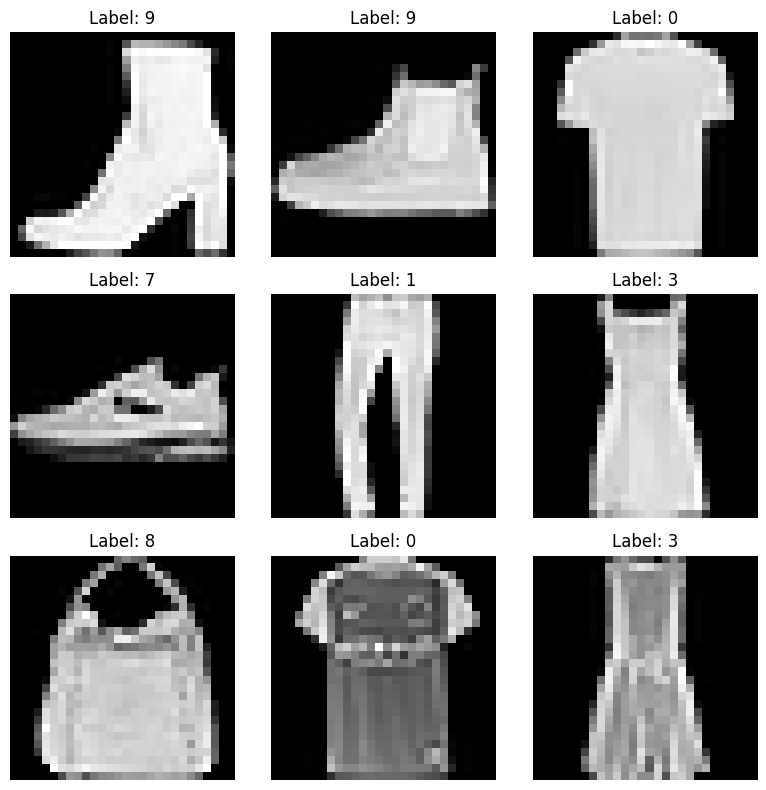

In [ ]:
import matplotlib.pyplot as plt
import random

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

# Randomly select 9 images from the training dataset
random_indices = random.sample(range(len(dm.train_dataset)), 9)

# Loop through each subplot and plot an image with its label
for i, ax in enumerate(axes.flat):
    # Get image and label from the dataset
    img, labelidx = dm.train_dataset[random_indices[i]]
    img = img.view(28, 28, 1)

    # Plot the image
    ax.imshow(img.squeeze(), cmap='gray')

    # Print the label
    ax.set_title(f'Label: {labelidx}')

    # Remove axes
    ax.axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



Let's dive deeper into the modified code to visualize a 3x3 grid of random images from the FashionMNIST dataset:

1. **Importing Libraries**: We start by importing the necessary libraries, including `matplotlib.pyplot` for visualization and `random` for generating random indices.

2. **Creating Subplots**:
   - We use `plt.subplots(3, 3, figsize=(8, 8))` to create a 3x3 grid of subplots with a specific size (8x8 inches).
   - This function returns a figure object (`fig`) and an array of axes objects (`axes`), which represent the individual subplots.

3. **Randomly Selecting Images**:
   - We generate 9 random indices using `random.sample(range(len(dm.train_dataset)), 9)`.
   - These indices are used to select 9 random images from the training dataset.
   - `len(dm.train_dataset)` returns the total number of images in the training dataset, and `random.sample()` selects 9 unique indices from this range.

4. **Plotting Images and Labels**:
   - We iterate over each subplot using `enumerate(axes.flat)`.
   - For each subplot, we retrieve the corresponding image and label from the dataset using the randomly selected indices.
   - The image is reshaped to match the dimensions expected by `imshow()` using `img.view(28, 28, 1)`.
   - We plot the image using `ax.imshow()` and specify `cmap='gray'` to display it in grayscale.
   - The label is printed as the title of the subplot using `ax.set_title(f'Label: {labelidx}')`.

5. **Removing Axes**:
   - We remove the axes from each subplot using `ax.axis('off')` to clean up the visualization.

6. **Adjusting Layout**:
   - We call `plt.tight_layout()` to adjust the layout of the subplots and prevent overlap between them.

7. **Displaying the Plot**:
   - Finally, we use `plt.show()` to display the plot containing the 3x3 grid of images.


#Understanding a PyTorch Lightning Model


This code defines a PyTorch Lightning module named `Mymodel`. Let's break down what each part does:

1. **Initialization**:
   - The `__init__` method initializes the model with parameters such as `input_shape`, `num_classes`, and `hidden_units`.
   - It defines the layers of the model using a list `layers`. The layers include a flattening layer, a series of fully connected (linear) layers with batch normalization and ReLU activation, and a final linear layer for classification.
   - It sets up the loss function (`nn.CrossEntropyLoss()`) and accuracy metric (`Accuracy`).

2. **Forward Pass**:
   - The `forward` method defines the forward pass of the model, which applies the defined layers to the input data.

3. **Optimizer Configuration**:
   - The `configure_optimizers` method specifies the optimizer used for training, in this case, Adam optimizer with a learning rate of 0.001.

4. **Training Step**:
   - The `training_step` method defines the operations performed during a single training step.
   - It computes the logits (raw predictions) using the forward pass, calculates the loss and accuracy, and logs them for monitoring.

5. **Validation and Test Steps**:
   - Similar to the training step, the `validation_step` and `test_step` methods define the operations during validation and testing.
   - They compute logits, calculate loss and accuracy, and log these metrics.

6. **Prediction Step**:
   - The `predict_step` method is optional and defined here for inference purposes. It performs the forward pass without computing loss or accuracy and returns the raw predictions.

7. **Instantiation**:
   - The model is instantiated with the specified `input_shape`, `num_classes`, and `hidden_units`.

Overall, this code provides a structured and modular way to define a neural network model for classification tasks using PyTorch Lightning, along with functionalities for training, validation, testing, and inference.

In [ ]:
class Mymodel(L.LightningModule):
    def __init__(self, input_shape, num_classes, hidden_units, lambda_L2=0.0):
        super().__init__()

        #self.classifier = nn.Sequential(
        #    nn.Flatten(),
        #    nn.Linear(input_shape, 16),
        #    nn.ReLU(),
        #    nn.Linear(16, num_classes)
        #)
        self.hidden_units = hidden_units  # Store the list of hidden units
        layers = []
        layers.append(nn.Flatten()) #input layer
        # Add hidden layers with ReLU activation
        for units in hidden_units: #hidden layers
            layers.append(nn.Linear(input_shape, units)) #logits
            layers.append(nn.BatchNorm1d(units))
            layers.append(nn.LeakyReLU(negative_slope=0.01))
            input_shape = units
        layers.append(nn.Linear(input_shape, num_classes))#output layer, logits
        self.classifier = nn.Sequential(*layers) # here the output are logits

        self.lambda_L2 = lambda_L2  # L2 regularization strength
        self.loss = nn.CrossEntropyLoss() #Multiclass
        self.accuracy = Accuracy(task="multiclass",  num_classes=num_classes)
    #for inference
    def forward(self, x):
        return self.classifier(x) #logits

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001, weight_decay=self.lambda_L2)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs) #this calls forward. Do not use .forward
        loss = self.loss(logits, labels) # here is the softmax function!

        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, labels)

        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs) #this calls forward
        loss = self.loss(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, labels)
        self.log('val_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('val_acc', acc, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs) #this calls forward
        loss = self.loss(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, labels)
        self.log('test_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('test_acc', acc, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss
    def predict_step(self, batch): #not necessary if dataloader with custom collate for prediction available (see OPTION 3 at the end of the notebook)
        # this calls forward for the inputs only
        inputs, labels = batch
        return self(inputs) #return logits, this calls forward

hidden_units = [32, 64, 16]  # Example hidden units list MLP, 3 hidden layers.
lambda_L2 = 0.0 #regularizer
model = Mymodel(input_shape=dm.input_shape, #28*28
                num_classes=dm.num_classes, #10
                hidden_units=hidden_units,
                lambda_L2=lambda_L2)#regularization L2




##Visualizing the model

A model visualization provides valuable insights into the structure and complexity of the neural network model, helping you understand its architecture and assess its capabilities.


The first way to visualize a model is by simply printing the `model` object. In PyTorch Lightning, the `model` is typically an instance of a LightningModule, which encapsulates the neural network model along with training and evaluation logic. By printing the `model`, you'll see its structure and possibly any attributes it contains.

In [ ]:
print(model) #hidden_units = [32 64 16]

Mymodel(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=64, out_features=16, bias=True)
    (8): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Linear(in_features=16, out_features=10, bias=True)
  )
  (loss): CrossEntropyLoss()
  (accuracy): MulticlassAccuracy()
)


Another way to visualize the model is using the `torchsummary` library

In [ ]:
from torchsummary import summary
# Use torchsummary to print the summary
summary(model.to(device), input_size=(1, 28, 28))  # input_size=(channels, height, width), channels=1 grayscale, channels=3 RGB color

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 32]          25,120
       BatchNorm1d-3                   [-1, 32]              64
         LeakyReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 64]           2,112
       BatchNorm1d-6                   [-1, 64]             128
         LeakyReLU-7                   [-1, 64]               0
            Linear-8                   [-1, 16]           1,040
       BatchNorm1d-9                   [-1, 16]              32
        LeakyReLU-10                   [-1, 16]               0
           Linear-11                   [-1, 10]             170
Total params: 28,666
Trainable params: 28,666
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

Let's break down the code:


```python
from torchsummary import summary
```

This line imports the `summary` function from the `torchsummary` library. This function is used to print a summary of the PyTorch model's architecture, including information about the layers, output shapes, and the total number of parameters.


```python
summary(model, input_size=(1, 28, 28))
```

Here, the `summary` function is called with two arguments:
- `model`: This is the PyTorch model. It represents the underlying neural network architecture.
- `input_size=(1, 28, 28)`: This specifies the input size expected by the model. The input size is defined as a tuple `(channels, height, width)`, where `1` indicates the number of channels (grayscale image), and `28` is the height and width of the input image from FMNIST dataset.

The `summary` function will then generate and print a summary of the model's architecture, which includes details such as:
- Layer names
- Output shapes of each layer
- Number of parameters (trainable and non-trainable)
- Total number of parameters in the model

# Understanding Callbacks in PyTorch Lightning for Enhanced Training Control

A callback in programming is a function or a piece of code that is passed as an argument to another function or method. It allows you to customize or extend the behavior of the function or method without modifying its actual code. In the context of machine learning frameworks like PyTorch Lightning, a callback is a piece of code that is executed at specific points during the training process, such as after each epoch or after a certain metric threshold is reached.

Concretely, we use the following callbacks

In [ ]:
# Initialize Callbacks
early_stop_callback = L.pytorch.callbacks.EarlyStopping(monitor="val_loss",
                                                        mode="min",
                                                        patience=3)
checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(save_top_k=5,
                                                          save_last=True,
                                                          monitor="val_loss",
                                                          mode='min')


Now, let's break down the code snippet:

1. **EarlyStopping Callback**:
   - `early_stop_callback` is initialized with an instance of the `EarlyStopping` callback.
   - This callback monitors the validation loss (`monitor="val_loss"`) and tries to minimize it (`mode="min"`).
   - It waits for `patience` number of epochs (in this case, 3 epochs) before considering stopping the training if the monitored quantity (validation loss) doesn't improve.

2. **ModelCheckpoint Callback**:
   - `checkpoint_callback` is initialized with an instance of the `ModelCheckpoint` callback.
   - This callback saves the model's checkpoints during training to disk.
   - It saves the top 5 models based on validation loss (`save_top_k=5`).
   - Additionally, it saves the last model (`save_last=True`) after training completes.
   - Similar to `EarlyStopping`, it monitors the validation loss (`monitor="val_loss"`) and tries to minimize it (`mode="min"`).


In summary, the provided code initializes two callbacks: `EarlyStopping` and `ModelCheckpoint`. These callbacks provide additional functionality to the training process, such as stopping training early if the model's performance stops improving (`EarlyStopping`) and saving model checkpoints for later use (`ModelCheckpoint`). These callbacks enhance the flexibility and functionality of the training loop, making it easier to manage and monitor the training process effectively.

#Setting up PyTorch Lightning Trainer

This code snippet demonstrates how to instantiate a PyTorch Lightning Trainer object with GPU acceleration if a CUDA-enabled GPU device is available, and without GPU acceleration if not. This flexibility allows the code to seamlessly adapt to different hardware configurations, optimizing performance based on available resources.

In [ ]:
trainer = None
print('*'*80)
print("You are using", device.type)
print('*'*80)
trainer = L.Trainer(max_epochs=50,
                    callbacks=[early_stop_callback, checkpoint_callback],
                    accelerator="gpu" if device.type == "cuda" else "cpu",
                    devices=1)#only works on script mode for devices > 1


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


********************************************************************************
You are using cuda
********************************************************************************



### Explanation:

1. **Checking Device Availability**:
   - The code checks if the `device` variable is set to `"cuda"`, indicating the presence of a CUDA-enabled GPU device.
   - If `device == "cuda"`, it signifies that the code will utilize GPU acceleration for training.

2. **Instantiating Trainer Object**:
   - If a GPU device is available (`device == "cuda"`), the Trainer object is instantiated with GPU acceleration enabled.
     - `max_epochs=50` specifies that the training will run for a maximum of 50 epochs.
     - `callbacks=[early_stop_callback, checkpoint_callback]` specifies a list of callbacks to be used during training, including early stopping and model checkpointing.
     - `accelerator="gpu"` indicates that GPU acceleration will be utilized.
     - `devices=1` specifies the number of GPU devices to use. Here, it's set to 1, indicating that only one GPU will be used for training.
   - If a GPU device is not available (`device != "cuda"`), the Trainer object is instantiated without GPU acceleration.
     - The parameters remain the same as above, but without specifying the `accelerator` or `devices` parameters. By default, if GPU acceleration is not specified, PyTorch Lightning will use CPU for training.


#Let's train the model

This code snippet illustrates the usage of the `fit()` method to train a PyTorch Lightning model (`model`) using data provided by a LightningDataModule (`dm`). It specifies the path for saving the model checkpoints during training (`ckpt_path='last'`) to ensure that the trained model's progress is saved for future use or evaluation.

In [ ]:
trainer.fit(model, dm,
            #checkpoint_callback.best_model_path  or 'best'.
            #use last if it is the first time you train.
            ckpt_path='last'
            )

Epoch 13/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1500/1500 0:00:38 • 0:00:00 38.43it/s v_num: 0.000 val_loss_step:     
                                                                                   0.148 val_acc_step: 0.938       
                                                                                   val_loss_epoch: 0.319           
                                                                                   val_acc_epoch: 0.886            

### Explanation:

- **trainer.fit() Method**:
  - `trainer.fit()` is a method provided by the PyTorch Lightning Trainer object, which is responsible for training the model.
  - It takes two main arguments:
    - The first argument (`model`) is the LightningModule instance that represents the neural network model to be trained.
    - The second argument (`dm`) is the LightningDataModule instance that provides the data loaders for training, validation, and testing.
  - In this case, `model` is the model object to be trained, and `dm` is the data module object that contains the data loaders necessary for training.

- **Checkpoint Path (`ckpt_path`)**:
  - The `ckpt_path` parameter specifies the path to load or save the model checkpoints during training.
  - In this code, `ckpt_path='last'` indicates that the Trainer will save the last model checkpoint after each epoch. This checkpoint will be used to resume training if interrupted or to evaluate the model after training.
  - Alternatively, the commented out line (`#checkpoint_callback.best_model_path or 'best'`) suggests an option to specify the path of the best model checkpoint based on a provided checkpoint callback (`checkpoint_callback`). It assumes that the `best_model_path` attribute of the `checkpoint_callback` contains the path to the best model checkpoint saved during training. If the attribute is not available or if the callback is not used, it defaults to `'best'`.


## Evaluating the model on the validation set

This code snippet demonstrates how to use the `validate()` method of the PyTorch Lightning Trainer object to evaluate a trained model (`model`) on a validation dataset. By specifying the data loader(s) for validation and the path to the model checkpoint, the Trainer ensures that the evaluation is performed using the best model obtained during training.

In [ ]:
trainer.validate(model, dataloaders=dm.val_dataloader(), ckpt_path='best')

Validation ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375/375 0:00:06 • 0:00:00 58.11it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_acc_epoch       │    0.8871666789054871     │
│      val_loss_epoch       │    0.31186288595199585    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss_epoch': 0.31186288595199585, 'val_acc_epoch': 0.8871666789054871}]

### Explanation:

- **trainer.validate() Method**:
  - `trainer.validate()` is a method provided by the PyTorch Lightning Trainer object, which is used for model validation.
  - It takes several arguments:
    - The first argument (`model`) is the LightningModule instance representing the neural network model to be evaluated.
    - The `dataloaders` argument specifies the data loader(s) to be used for validation. In this case, it's provided as `dm.val_dataloader()`, which returns the validation data loader from the given LightningDataModule (`dm`).
    - The `ckpt_path` parameter specifies the path to load the model checkpoint before validation. In this code snippet, `ckpt_path='best'` indicates that the Trainer will load the best model checkpoint saved during training for validation. This ensures that the best-performing model is used for evaluation.

&nbsp;
&nbsp;
&nbsp;

----
# Visualize the training process

The `%tensorboard --logdir lightning_logs` command launches TensorBoard and instructs it to load the log files from the `lightning_logs` directory. TensorBoard then displays visualizations of the training progress, including metrics, loss curves, histograms of model parameters, and more, allowing you to analyze and monitor the performance of your PyTorch Lightning models interactively.

### Explanation:
- The `%load_ext tensorboard` command is a Jupyter Notebook magic command used to load the TensorBoard extension within the Jupyter Notebook environment.
- **`%tensorboard` Magic Command**:
  - The `%tensorboard` command is a Jupyter Notebook magic command that allows you to launch TensorBoard directly within the Jupyter Notebook environment.
  - This command is typically used when you want to visualize logs and metrics generated during the training of machine learning models.

- **`--logdir` Argument**:
  - The `--logdir` argument specifies the directory where the log files are stored. In this case, it's set to `lightning_logs`.
  - PyTorch Lightning automatically logs various metrics, such as loss, accuracy, etc., during training, validation, and testing stages. These logs are saved in the `lightning_logs` directory by default.





In [ ]:
# Load the TensorBoard notebook extension
#%load_ext tensorboard
# No funciona con entornos de ejecución locales ()
%reload_ext tensorboard

In [ ]:
%tensorboard --logdir "/content/lightning_logs"


<IPython.core.display.Javascript object>

&nbsp;
&nbsp;
&nbsp;

----

# Test the model

This code snippet demonstrates how to use the `test()` method of the PyTorch Lightning Trainer object to evaluate a trained model (`model`) on a test dataset. By specifying the data loader(s) for testing and the path to the model checkpoint, the Trainer ensures that the evaluation is performed using the best model obtained during training.

In [ ]:
# test the model
#dm.setup(stage='test')
trainer.test(model, dataloaders=dm.test_dataloader(), ckpt_path='best')

Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313/313 0:00:05 • 0:00:00 58.55it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.8812000155448914     │
│      test_loss_epoch      │    0.33349084854125977    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.33349084854125977,
  'test_acc_epoch': 0.8812000155448914}]

### Explanation:

- **`trainer.test()` Method**:
  - `trainer.test()` is a method provided by the PyTorch Lightning Trainer object, used for model evaluation on a test dataset.
  - It takes several arguments:
    - The first argument (`model`) is the LightningModule instance representing the neural network model to be evaluated.
    - The `dataloaders` argument specifies the data loader(s) to be used for testing. In this case, it's provided as `dm.test_dataloader()`, which  returns the test data loader from the given LightningDataModule (`dm`).
    - The `ckpt_path` parameter specifies the path to load the model checkpoint before testing. In this code snippet, `ckpt_path='best'` indicates that the Trainer will load the best model checkpoint saved during training for testing. This ensures that the best-performing model is used for evaluation.


# Making predictions: Inference stage

Inference, in the context of deep learning, refers to the process of using a trained neural network model to make predictions or draw conclusions from new, unseen data. During inference, input data is fed into the trained model, which processes the data through its layers to produce output predictions. These predictions could include class labels, regression values, or any other desired outcome depending on the task at hand.

In PyTorch Lightning, there are two distinct stages in which a trained model is evaluated: the **predict (inference)** stage and the **test** stage. Here's a clarification of the difference between these two stages:

1. **Predict (Inference) Stage**:
   - **Purpose**: The predict stage is primarily focused on making predictions or inferences on new, unseen data.
   - **Usage**: It is used when you want to apply the trained model to new data to obtain predictions or outputs.
   - **Input**: Typically, input data is provided to the model for inference, and the model's output predictions are obtained.
   - **Scenario**: This stage is commonly used in real-world applications where the trained model is deployed to make predictions on user input, images, text, or any other data.
   - **Flexibility**: PyTorch Lightning provides flexibility in conducting inference, allowing you to override the `predict_step` method in your LightningModule to customize the inference process.

2. **Test Stage**:
   - **Purpose**: The test stage is focused on evaluating the performance of the trained model on a separate test dataset.
   - **Usage**: It is used to assess the generalization ability and overall performance of the model on unseen data.
   - **Input**: Input data from the test dataset is provided to the model, and predictions are compared against ground-truth labels to compute evaluation metrics such as accuracy, precision, recall, etc.
   - **Scenario**: This stage is commonly used during model development and experimentation to validate the model's performance before deployment.
   - **Evaluation**: PyTorch Lightning provides convenience methods like `trainer.test()` to automate the evaluation process during the test stage. These methods handle the forward pass, compute metrics, and provide evaluation results.



In PyTorch Lightning, there are multiple approaches to perform inference, each with its own advantages and considerations. These approaches range from leveraging PyTorch Lightning's built-in capabilities, such as overriding the `predict_step` method, to more manual methods like directly calling the model's `forward` method. Each approach offers flexibility and trade-offs in terms of simplicity, efficiency, and customization.


Here, we present 3 options to perform predictions. **Option 1** is the preferred method as it leverages PyTorch Lightning's built-in capabilities and is more streamlined. **Option 1** and **Option 2** are commented.


### Option 1:
This option demonstrates the preferred method for making inferences in PyTorch Lightning by overriding the `predict_step` method. Here's how it works:

- **Predict Step Override**:
  - The `predict_step` method is overridden within the LightningModule (see above the neural network model).
  - In this method, you call the `forward` method directly. This is the same method used during training and validation but tailored specifically for inference.
  - You don't need to call `eval()` or use `torch.no_grad()` explicitly, as PyTorch Lightning handles this internally.
  
- **Inference Process**:
  - The LightningDataModule is set up for inference using `dm.setup(stage='predict')`.
  - The Trainer's `predict` method is called, passing the model and the dataloader for inference.
  - Predicted logits are obtained, and softmax is applied to obtain probabilities.
  - Predicted labels are inferred from probabilities.
  - Ground-truth labels are extracted for comparison.
  - Finally, the probabilities are visualized.

### Option 2 (commented in the code below):
This option demonstrates an alternative approach where you define a custom dataloader that only returns inputs for inference:

- **Custom Dataloader**:
  - You define a custom collate function (`custom_collate`) to extract only the inputs from the batch.
  - The dataloader is set up with this custom collate function.
  
- **Inference Process**:
  - The Trainer's `predict` method is called, passing only the dataloader (as it now only returns inputs).
  - Predicted logits are obtained.
  
- **No Predict Step**:
  - Options 2 does not require a `predict_step` method like option 1. Instead, it relies on custom dataloaders.

### Option 3:
This option demonstrates directly calling the `forward` method for inference through `model(inputs)`:

- **Using `forward`**:
  - You directly call the `forward` method of the model.
  - You must manually handle model evaluation (`eval()`) and gradient tracking suppression (`torch.no_grad()`).

- **Inference Process**:
  - The model is set to evaluation mode using `model.eval()`.
  - Inference is performed directly by calling the `forward` method on inputs.
  - Gradient tracking is disabled within the `torch.no_grad()` context.
  - Predicted logits are obtained.
  
- **No Predict Step**:
  - Options 3 does not require a `predict_step` method like option 1. Instead, it relies on direct `forward` calls for inference through `model(inputs)`. Note that by calling model(inputs), you're implicitly invoking the forward method of the model.


Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s

pred_logits[0].shape is torch.Size([5, 10])
predicted_probs_list is [tensor([[1.2073e-07, 2.8096e-07, 1.8023e-07, 1.2518e-08, 2.6462e-07, 2.7506e-03,
         2.2318e-07, 6.8669e-03, 1.1846e-06, 9.9038e-01],
        [1.5031e-05, 1.7501e-07, 9.9822e-01, 6.6439e-09, 1.2509e-03, 7.9345e-06,
         5.0764e-04, 5.3767e-08, 3.8046e-08, 6.0558e-08],
        [6.0650e-07, 9.9999e-01, 2.1043e-07, 1.7828e-07, 1.3747e-08, 1.0767e-07,
         8.8762e-07, 2.6136e-08, 3.8074e-06, 1.4691e-08],
        [3.9935e-07, 1.0000e+00, 6.6604e-07, 3.6356e-07, 4.4173e-08, 1.9646e-07,
         1.7104e-06, 7.1938e-09, 3.1411e-08, 3.8985e-07],
        [2.1879e-01, 6.0034e-05, 8.4588e-02, 2.5495e-03, 6.9885e-03, 6.9358e-04,
         6.8405e-01, 6.3735e-05, 2.1743e-03, 4.6012e-05]])]
predicted_labels_list is [tensor([9, 2, 1, 1, 6])]
labels_list is [9, 2, 1, 1, 6]


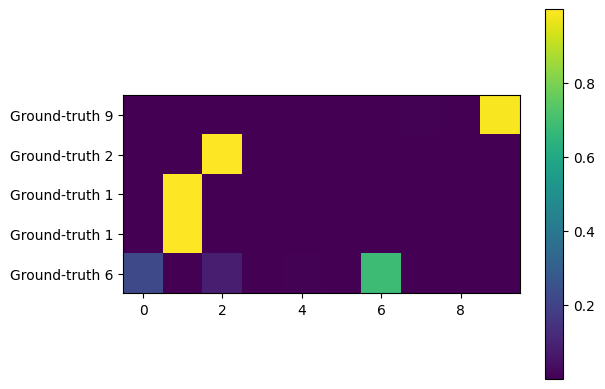

In [ ]:
#OPTION 1 (PREFERRED). overrides predict_step that calls forward

#this calls the overridden predict_step which in turn calls forward.
# no need to call eval() or no_grad()

#dm.setup(stage='predict')
pred_logits = trainer.predict(model, dataloaders=dm.predict_dataloader(), ckpt_path='best')
print("pred_logits[0].shape is", pred_logits[0].shape)

# Assuming 'pred_logits' is a list of tensors, e.g., [tensor1, tensor2, tensor3, ...]
# Get the predicted probs for each example in the list using softmax
predicted_probs_list = [torch.softmax(logits, dim=1) for logits in pred_logits]
print("predicted_probs_list is", predicted_probs_list)
# 'predicted_labels_list' now contains the inferred class labels for each example
predicted_labels_list = [torch.argmax(probs, dim=1) for probs in predicted_probs_list]
print("predicted_labels_list is", predicted_labels_list)
# Assuming your DataLoader returns (inputs, labels) for each batch
# Use list comprehension to extract labels for all examples in the DataLoader
labels_list = [labels for _, labels in [batch for batch in dm.predict_dataloader()]]
labels_list = labels_list[0].tolist() # because the previous step return a torch tensor inside a list. The 0th element is the torch tensor
# 'labels_list' now contains the labels for all examples in the DataLoader

print("labels_list is", labels_list)

#visualize the probabilities
# Stack the list of tensors into a 2D tensor
stacked_tensor = torch.stack(predicted_probs_list, dim=0).view(5,10)
# Reshape the 2D tensor into a 2D numpy array
numpy_array = stacked_tensor.numpy()
# Visualize the 2D numpy array as an image
plt.imshow(numpy_array, cmap='viridis')  # You can choose a different colormap
# Convert the tensors in labels_list to strings
string_labels = [str(label) for label in labels_list]
prefixed_strings = ["Ground-truth " + string for string in string_labels]
# Set the y tick labels to the string values
plt.yticks(range(len(string_labels)), prefixed_strings)
plt.colorbar()
plt.show()


#OPTION 2 no predict_step needed. Need to define a dataloader that returns only the inputs
#def custom_collate(batch):
#    # Extract only the inputs and return them as a list
#    list_inputs = [item[0] for item in batch]
#    stacked_inputs = torch.stack(list_inputs, dim=0)
#    return stacked_inputs

#imgx, labelx = test_dataset[0]
#predict_dataset = data.TensorDataset(imgx)
#predict_dataloader = data.DataLoader(predict_dataset, batch_size=1, collate_fn=custom_collate)
#print(predict_dataloader.dataset[0])
#pred_logits = trainer.predict(dataloaders=predict_dataloader)
#print((pred_logits[0]))


# OPTION 3, calling directly forward.
#When using forward, you are responsible to call eval() and use the no_grad() context manager.
#model.eval()
#with torch.no_grad():
#    inputs, lab = test_dataloader.dataset[0]
#    pred = model(inputs) #this calls forward
#    print(pred)



#Visualizing the model with Tensorboard

In [ ]:
from torch.utils.tensorboard import SummaryWriter
X_probe = torch.randn(5,28,28) #just a (batch,width, height) probe input
writer = SummaryWriter("torchlogs/")
writer.add_graph(model, X_probe)
writer.close()

In [ ]:
%tensorboard --logdir torchlogs # requieres to previously execute in juypter %load_ext tensorboard

In [ ]:
#ADVANCED VISUALIZATION WITH TORCHVIZ
#!pip install torchviz

In [ ]:
#ADVANCED VISUALIZATION WITH TORCHVIZ
#from torchviz import make_dot
#X_probe = torch.randn(5,28,28) #just a (batch,width, height) probe input
#y = model(X_probe)
#make_dot(y.mean(), params=dict(model.named_parameters()), show_attrs=True, show_saved=True)

# ✅ Activity: K-Fold Cross-Validation

Modify the code to incorporate K-Fold Cross-Validation (CV) to optimize the number of neurons in each hidden layer. Keep the number of hidden layers fixed at 3, the L2 regularization parameter fixed at 1e-4, and vary the number of neurons in each hidden layer using the following values: 16, 64, and 256. For this activity, utilize `sklearn.model_selection.StratifiedKFold` with a random seed of 42. Test your code with `k=5` and complete the table below with the accuracy for each run. Additionally, calculate the p-value using the model with 16 neurons as the pivot. Analyze which of the three models is the best.

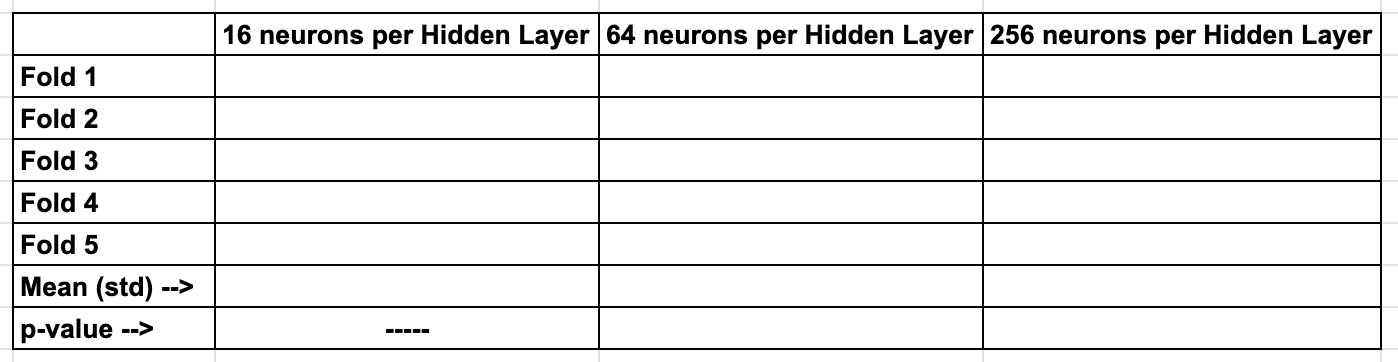

# ✅ Activity: Implementing L1 Regularization

Modify the model to accept a new hyperparameter `Lambda_L1` to implement L1 regularization. Note that `torch.optim.Adam` does not implement L1 regularization. Tip: Modify `training_step` to include the L1 norm in the loss function calculation. You don’t need to do k-fold cross-validation. Just run your implementation once to check if it works correctly.

#References

[1] https://lightning.ai/

[2] https://www.appsilon.com/post/visualize-pytorch-neural-networks